In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
import numpy as np
import concurrent.futures
import time
from tqdm import tqdm  # 引入 tqdm

In [3]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    
    # 构造复能量矩阵 (简化的写法，等价于你的 EI_gai)
    EI_gai = (E + 1j * eta) * np.eye(d, dtype=complex)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 G_00 和 G_01
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12
    
    # 3. Right-to-Left 扫掠：只记录向右连通的等效格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 格林函数 G_00 (原 G_DD_r[0:4, 0:4])
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出左上角右侧相邻的 4x4 非对角块 G_01 (原 G_DD_r[0:4, 4:8])
    # 根据 Dyson 方程，G_01 = G_00 * V_01 * gR_1
    #G_01 = G_00 @ V @ gR[1]

    # 返回你需要的结果 (去掉了庞大无用的 A_DD)
    return G_00, G_00, Sigma_R, Sigma_L

def bufeng(G_00):
    d = H_q.shape[0]
    yigeshu=np.trace(G_00)
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    
    # 构造松原频率复能量矩阵
    # 假设外部已经定义了 s0 = np.eye(2, dtype=complex)
    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 Matsubara G_00, G_01 和 G_10
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12

    # 特殊情况防错：如果 N=1，只有1个格点
    if N == 1:
        G_00 = np.linalg.inv(ALR - Sigma_L - Sigma_R)
        G_01 = np.zeros((d, d), dtype=complex)
        G_10 = np.zeros((d, d), dtype=complex)
        return G_00, G_01, G_10, Sigma_R, Sigma_L

    # 3. Right-to-Left 扫掠：只记录向右连通的等效松原格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 松原格林函数 G_00
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出右侧相邻的非对角块 G_01
    # 公式: G_{0,1} = G_{0,0} * V * gR_1
    G_01 = G_00 @ V @ gR[1]

    # 6. 算出下方相邻的非对角块 G_10
    # 公式: G_{1,0} = gR_1 * V^\dagger * G_{0,0}
    G_10 = gR[1] @ V.conj().T @ G_00

    # 返回优化后的结果 
    return G_00, G_01, G_10, Sigma_R, Sigma_L

def J_wn(G_01, G_10, T_12):
    d = T_12.shape[0]

    G_q_q1 = G_01
    G_q1_q = G_10

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        _, G_01, G_10, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_01, G_10, T_12))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onsite(hx,hz,saimanjiao,1,phi,t)
    H_q = H_onsite(mx,mz,zhongjian_saimanjiao,2,phi,t)
    H_r = H_onsite(hx,hz,saimanjiao,3,phi,t)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N)
    return Jphi

def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [19]:
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(weineng, mu, Delta, chaodaojiao):
    Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
    HX_block=(weineng- mu)*s0 
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t):
    H_X_L_to_R_hop_block=-t*s0
    return np.block([
        [ H_X_L_to_R_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_L_to_R_hop_block.conj() ]
    ])

#参数
t =-1

dela = 0.1*t
Delta = dela
#chaodaojiao = 0 #可变

mu =0
a=1

weineng_a=-1.1*t
weineng_b=0.7*t

#中间
tc= 0.6*t

#omega = 144 / 233
omega = 89/ 144
# 左边超导体
yigejiao_L = 0.9 * np.pi
N_L = 233
weineng_L_list = []
for j in range(1, N_L + 1):  
    X_j = np.sign(np.cos(2 * np.pi * j * omega + yigejiao_L) - np.cos(np.pi * omega))
    if X_j >= 0:
        weineng_L_list.append(weineng_a)
    if X_j < 0:
        weineng_L_list.append(weineng_b)
#weineng_L_list, total_len, count_a, count_b = generate_sequence(12, weineng_a, weineng_b)

# 右边超导体
yigejiao_R = 0.45 * np.pi  
N_R = 233
weineng_R_list = []
for j in range(1, N_R + 1):  
    X_j = np.sign(np.cos(2 * np.pi * j * omega + yigejiao_R) - np.cos(np.pi * omega))
    if X_j >= 0:
        weineng_R_list.append(weineng_a)
    if X_j < 0:
        weineng_R_list.append(weineng_b)
#weineng_R_list, total_len, count_a, count_b = generate_sequence(12, weineng_a, weineng_b)



#左边矩阵信息
#H_L_onsite_list = [] #下更新，这里是例子
#for weineng in weineng_L_list:
#    H_L_onsite_list.append(H_onsite(weineng, mu, Delta, chaodaojiao))
H_L_left_to_right_hop=H_hop(t)

#中间矩阵信息
H_center_left_to_right_hop=H_hop(tc)

#右边矩阵信息
H_R_onsite_list = []
for weineng in weineng_R_list:
    # 右侧的超导相位设为0，作为参考相位
    H_R_onsite_list.append(H_onsite(weineng, mu, Delta, 0))
H_R_left_to_right_hop=H_hop(t)

In [20]:
def build_full_Hamiltonian(H_L_onsite_list, H_L_left_to_right_hop, 
                           H_center_left_to_right_hop, 
                           H_R_onsite_list, H_R_left_to_right_hop):
    """
    根据左、右超导体的在位矩阵列表和跃迁矩阵，拼接完整的 BdG 哈密顿量。
    """
    N_L = len(H_L_onsite_list)
    N_R = len(H_R_onsite_list)
    N_total = N_L + N_R
    
    # 每个格点矩阵的维度是 4x4 (Nambu空间 x 自旋)
    dim = 4 
    
    # 初始化一个巨大的全零复数矩阵
    H_full = np.zeros((N_total * dim, N_total * dim), dtype=complex)
    
    # 1. 拼接主对角线 (On-site 项)
    # 把左右两边的列表接在一起，方便统一遍历
    H_onsite_all = H_L_onsite_list + H_R_onsite_list 
    
    for i in range(N_total):
        # 提取当前格点在超级大矩阵中的行和列的起始/终止索引
        row_start, row_end = i * dim, (i + 1) * dim
        col_start, col_end = i * dim, (i + 1) * dim
        
        # 将在位矩阵块填入对角线
        H_full[row_start:row_end, col_start:col_end] = H_onsite_all[i]
        
    # 2. 拼接上下一次对角线 (Hopping 项)
    for i in range(N_total - 1):
        # 确定当前点 i 到相邻点 i+1 的跃迁矩阵是什么
        if i < N_L - 1:
            # 还在左侧超导体内部
            current_hop = H_L_left_to_right_hop
        elif i == N_L - 1:
            # 刚好在结的中间！连接左侧最后一个点 (N_L-1) 和右侧第一个点 (N_L)
            current_hop = H_center_left_to_right_hop
        else:
            # 已经进入右侧超导体内部
            current_hop = H_R_left_to_right_hop
            
        # 索引计算：i 是前一个点，i+1 是后一个点
        # 前的行，后的列 -> 上对角线
        upper_row_start, upper_row_end = i * dim, (i + 1) * dim
        upper_col_start, upper_col_end = (i + 1) * dim, (i + 2) * dim
        H_full[upper_row_start:upper_row_end, upper_col_start:upper_col_end] = current_hop
        
        # 后的行，前的列 -> 下对角线 (跃迁矩阵的共轭转置)
        lower_row_start, lower_row_end = (i + 1) * dim, (i + 2) * dim
        lower_col_start, lower_col_end = i * dim, (i + 1) * dim
        H_full[lower_row_start:lower_row_end, lower_col_start:lower_col_end] = current_hop.conj().T
        
    return H_full

In [14]:
def build_full_Hamiltonian_1(H_L_onsite_list, H_L_left_to_right_hop, 
                                 H_center_left_to_right_hop, 
                                 H_R_onsite_list, H_R_left_to_right_hop):
    """
    使用 np.block 直观拼接完整的 BdG 哈密顿量。
    完全按照物理上的“分块矩阵”思想构建。
    """
    N_L = len(H_L_onsite_list)
    N_R = len(H_R_onsite_list)
    N_total = N_L + N_R
    dim = 4
    
    # 1. 先创建一个完全由 4x4 零矩阵填充的二维列表（也就是块矩阵的骨架）
    # blocks[row][col] 就对应着你说的第 row+1 行，第 col+1 列的块
    blocks = [[np.zeros((dim, dim), dtype=complex) for _ in range(N_total)] for _ in range(N_total)]
    
    # 将左右两边的在位矩阵合并到一个列表，方便遍历
    H_onsite_all = H_L_onsite_list + H_R_onsite_list
    
    # 2. 填充主对角线 (即你说的 11, 22, 33, 44 位置)
    for i in range(N_total):
        blocks[i][i] = H_onsite_all[i]
        
    # 3. 填充相邻的跳跃项 (即你说的 12, 23, 34 以及它们对称的 21, 32, 43 位置)
    for i in range(N_total - 1):
        # 判断当前跨越的是什么类型的边界
        if i < N_L - 1:
            # 左侧超导体内部 (比如 12)
            hop = H_L_left_to_right_hop
        elif i == N_L - 1:
            # 刚好在结的中间！(比如 N_L=2 时，这里是 i=1，也就是 23 位置)
            hop = H_center_left_to_right_hop
        else:
            # 右侧超导体内部 (比如 34)
            hop = H_R_left_to_right_hop
            
        # 严格按照坐标填入块矩阵
        blocks[i][i+1] = hop                  # 右上角的块 (比如 12, 23, 34)
        blocks[i+1][i] = hop.conj().T         # 左下角的块 (比如 21, 32, 43)
        
    # 4. 见证奇迹：使用 np.block 将二维列表直接拼成一个巨大的一维展开矩阵
    H_full = np.block(blocks)
    
    return H_full


In [7]:
def build_full_Hamiltonian_jiadaindx(H_L_onsite_list, H_L_left_to_right_hop, 
                           H_center_left_to_right_hop, 
                           H_R_onsite_list, H_R_left_to_right_hop):
    """
    根据左超导体、中间正常区域、右超导体的在位矩阵列表和跃迁矩阵，拼接完整的 BdG 哈密顿量。
    （中间 20 个正常态格点直接在内部生成）
    """
    N_L = len(H_L_onsite_list)
    N_R = len(H_R_onsite_list)
    
    # ================= 新增：在内部直接定义中间区域 =================
    N_C = 20  # 中间加入 20 个格点
    # 在位能量: weineng=1, mu=0, Delta=0, chaodaojiao=0
    H_C_onsite_list = [H_onsite(weineng=1, mu=0, Delta=0, chaodaojiao=0) for _ in range(N_C)]
    
    # 内部跳跃矩阵，这里直接借用传入的 H_L_left_to_right_hop，也就是 H_hop(t)
    H_C_left_to_right_hop = H_L_left_to_right_hop 
    # ================================================================
    
    N_total = N_L + N_C + N_R
    
    # 每个格点矩阵的维度是 4x4 (Nambu空间 x 自旋)
    dim = 4 
    
    # 初始化一个巨大的全零复数矩阵
    H_full = np.zeros((N_total * dim, N_total * dim), dtype=complex)
    
    # 1. 拼接主对角线 (On-site 项)
    # 把左、中、右三个区域的在位矩阵列表接在一起，统一遍历
    H_onsite_all = H_L_onsite_list + H_C_onsite_list + H_R_onsite_list 
    
    for i in range(N_total):
        row_start, row_end = i * dim, (i + 1) * dim
        col_start, col_end = i * dim, (i + 1) * dim
        H_full[row_start:row_end, col_start:col_end] = H_onsite_all[i]
        
    # 2. 拼接上下一次对角线 (Hopping 项)
    for i in range(N_total - 1):
        # 确定当前点 i 到相邻点 i+1 的跃迁矩阵是什么
        if i < N_L - 1:
            # 左侧超导体内部
            current_hop = H_L_left_to_right_hop
            
        elif i == N_L - 1:
            # 【交界面 1】：连接左侧最后一个点和中间区域第一个点
            current_hop = H_center_left_to_right_hop
            
        elif i < N_L + N_C - 1:
            # 中间区域内部
            current_hop = H_C_left_to_right_hop
            
        elif i == N_L + N_C - 1:
            # 【交界面 2】：连接中间区域最后一个点和右侧第一个点
            current_hop = H_center_left_to_right_hop
            
        else:
            # 右侧超导体内部
            current_hop = H_R_left_to_right_hop
            
        # 填充上对角线
        upper_row_start, upper_row_end = i * dim, (i + 1) * dim
        upper_col_start, upper_col_end = (i + 1) * dim, (i + 2) * dim
        H_full[upper_row_start:upper_row_end, upper_col_start:upper_col_end] = current_hop
        
        # 填充下对角线 (跃迁矩阵的共轭转置)
        lower_row_start, lower_row_end = (i + 1) * dim, (i + 2) * dim
        lower_col_start, lower_col_end = i * dim, (i + 1) * dim
        H_full[lower_row_start:lower_row_end, lower_col_start:lower_col_end] = current_hop.conj().T
        
    return H_full

    

In [21]:
phases = np.linspace(0, 2 * np.pi, 20)

all_phases = []
all_energies = []

# 定义一个供线程调用的计算函数
def compute_eigenvalues_for_phi(phi):
    # 1. 用当前的相位 phi 更新左侧的在位矩阵列表
    H_L_onsite_list_current = [H_onsite(w, mu, Delta, phi) for w in weineng_L_list]
    
    # 2. 拼接完整的 BdG 哈密顿量
    H_system = build_full_Hamiltonian(H_L_onsite_list_current, 
                                      H_L_left_to_right_hop, 
                                      H_center_left_to_right_hop, 
                                      H_R_onsite_list, 
                                      H_R_left_to_right_hop)
    
    # 3. 求解本征值
    evals = np.linalg.eigvalsh(H_system)
    
    # 4. 返回当前 phi 及其对应的特征值
    return phi, evals

print("启动 10 线程并发计算...")
start_time = time.time()

# 使用 ThreadPoolExecutor 管理 10 个线程
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    # 提交所有任务
    future_to_phi = {executor.submit(compute_eigenvalues_for_phi, phi): phi for phi in phases}
    
    # 使用 tqdm 包装 as_completed 迭代器，total 告诉 tqdm 一共有多少个任务
    for future in tqdm(concurrent.futures.as_completed(future_to_phi), total=len(phases), desc="对角化进度", ncols=80):
        phi_val = future_to_phi[future]
        try:
            phi_res, evals = future.result()
            
            # 保存作图数据
            all_phases.extend([phi_res] * len(evals))
            all_energies.extend(evals)
            
        except Exception as exc:
            # 使用 tqdm.write 可以在不打断进度条显示的情况下打印错误信息
            tqdm.write(f"phi = {phi_val/np.pi:.3f} * pi 产生异常: {exc}")

end_time = time.time()
print(f"全部计算完成！总耗时: {end_time - start_time:.2f} 秒")


启动 10 线程并发计算...


对角化进度: 100%|███████████████████████████████| 20/20 [00:11<00:00,  1.68it/s]

全部计算完成！总耗时: 11.94 秒


计算完成，正在绘图...


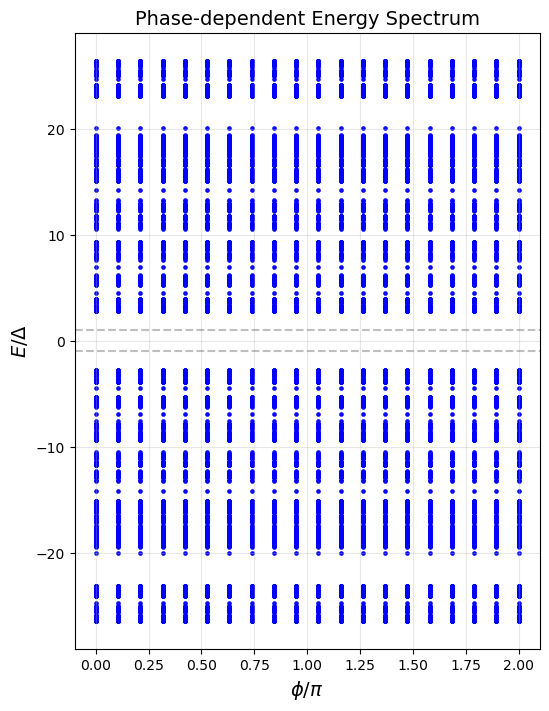

In [22]:
print("计算完成，正在绘图...")

# 将列表转换为 numpy 数组，并进行归一化处理以便对比论文
all_phases_arr = np.array(all_phases) / np.pi
all_energies_arr = np.array(all_energies) / dela

# 绘图
plt.figure(figsize=(6, 8))
plt.scatter(all_phases_arr, all_energies_arr, s=5, c='blue', alpha=0.7)

#plt.ylim(-5, 5)
#plt.xlim(0, 2)

# 设置标签和标题
plt.xlabel(r'$\phi / \pi$', fontsize=14)
plt.ylabel(r'$E / \Delta$', fontsize=14)
plt.title('Phase-dependent Energy Spectrum', fontsize=14)

# 添加参考线：超导能隙边界 +-1
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(-1, color='gray', linestyle='--', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.show()